# PDF Table Extractor + Analyzer — 02 Analysis

With the tables now as DataFrames, we analyse them: total revenue by region and fastest-growing expense categories. All numbers are run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
tables=utils.extract_tables()
rev=utils.to_dataframe(tables[0],numeric_cols=['Q1','Q2','Q3','Q4'])
exp=utils.to_dataframe(tables[1],numeric_cols=['2023','2024','Change %'])

## 1. Total 2024 revenue by region

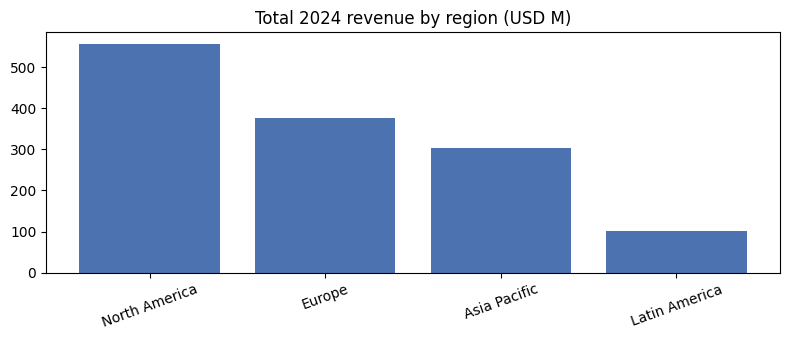

{'North America': 556.8, 'Europe': 377.3, 'Asia Pacific': 303.8, 'Latin America': 102.6}
company-wide 2024 revenue: $1340.5M


In [2]:
rev['Total']=rev[['Q1','Q2','Q3','Q4']].sum(axis=1)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.bar(rev.Region,rev.Total,color='#4c72b0'); ax.set_title('Total 2024 revenue by region (USD M)'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
print(dict(zip(rev.Region,rev.Total.round(1))))
print('company-wide 2024 revenue: $%.1fM'%rev.Total.sum())

## 2. Revenue trend across quarters

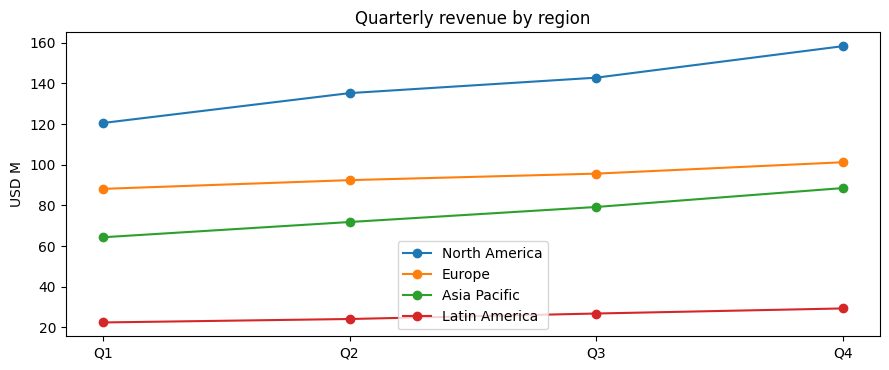

In [3]:
fig,ax=plt.subplots(figsize=(9,3.8))
for _,r in rev.iterrows(): ax.plot(['Q1','Q2','Q3','Q4'],[r.Q1,r.Q2,r.Q3,r.Q4],marker='o',label=r.Region)
ax.legend(); ax.set_title('Quarterly revenue by region'); ax.set_ylabel('USD M'); plt.tight_layout(); plt.show()

## 3. Fastest-growing expenses

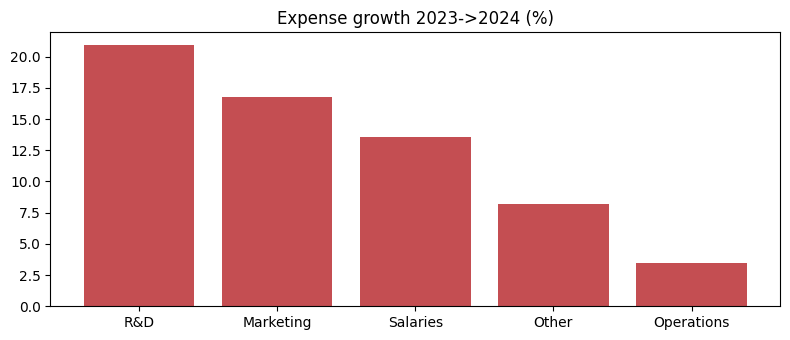

{'R&D': 20.9, 'Marketing': 16.8, 'Salaries': 13.6, 'Other': 8.2, 'Operations': 3.5}


In [4]:
e=exp.sort_values('Change %',ascending=False)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.bar(e.Category,e['Change %'],color='#c44e52'); ax.set_title('Expense growth 2023->2024 (%)'); plt.tight_layout(); plt.show()
print(dict(zip(e.Category,e['Change %'])))

## 4. Summary & takeaways

- **pdfplumber turns locked PDF tables into analysable DataFrames** — both the revenue and expense tables were recovered exactly, headers and numbers intact.
- **Revenue analysis**: North America leads (~\$556.8M total 2024), followed by Europe (~\$377.3M) and Asia Pacific (~\$303.8M); every region grows quarter-on-quarter.
- **Expense analysis**: R&D is the fastest-growing cost (+20.9%), then Marketing (+16.8%) and Salaries (+13.6%) — spend is tilting toward growth investments.
- **The pipeline generalises**: swap in any report PDF and the same extract → to_dataframe → analyse flow applies (with more cleaning for messier real-world layouts).